<a href="https://colab.research.google.com/github/Anshitha9286/ASSIGNMENT/blob/main/Diabetes_ANN_Module_End.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

##Loading and Preprocessing

In [3]:
data = load_diabetes(as_frame=True)
df = data.frame
print(df.shape)
df.head()

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


The dataset has 442 patients and 10 features, plus the target, which is a measure of disease progression one year after baseline. The feature names are age, sex, bmi, bp, s1–s6. The s columns are blood serum measurements: s1 = total cholesterol, s2 = LDL, s3 = HDL, s4 = total/HDL ratio, s5 = log of triglycerides, s6 = blood sugar.

##Check for missing values

In [4]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


### Train/test split and normalization
The data is split 80/20 (353 training and 89 test patients, random_state = 42). The features are standardized with StandardScaler (mean 0, standard deviation 1), fitted on the training set only and then applied to the test set, so no information from the test data leaks into training. The target is also scaled, because neural networks train faster and more stably when the target is around zero. Predictions are converted back to the original units before computing the metrics.

In [5]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features: fit on TRAIN only, then apply to test (avoids data leakage)
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)

# Scale the target too, because neural nets train much faster when y is around 0
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_s = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print(X_train_s.shape, X_test_s.shape)

(353, 10) (89, 10)


#Exploratory Data Analysis

In [6]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


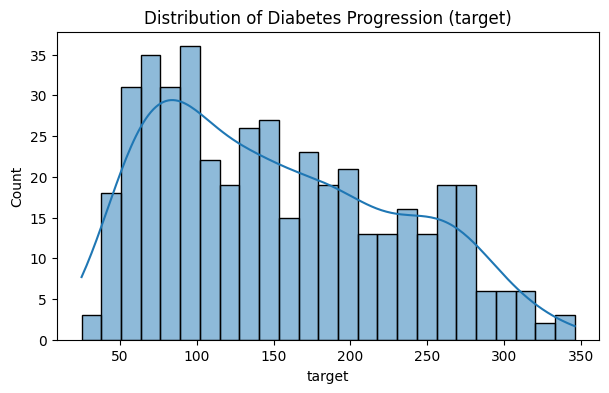

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(df['target'], kde=True, bins=25)
plt.title('Distribution of Diabetes Progression (target)')
plt.show()

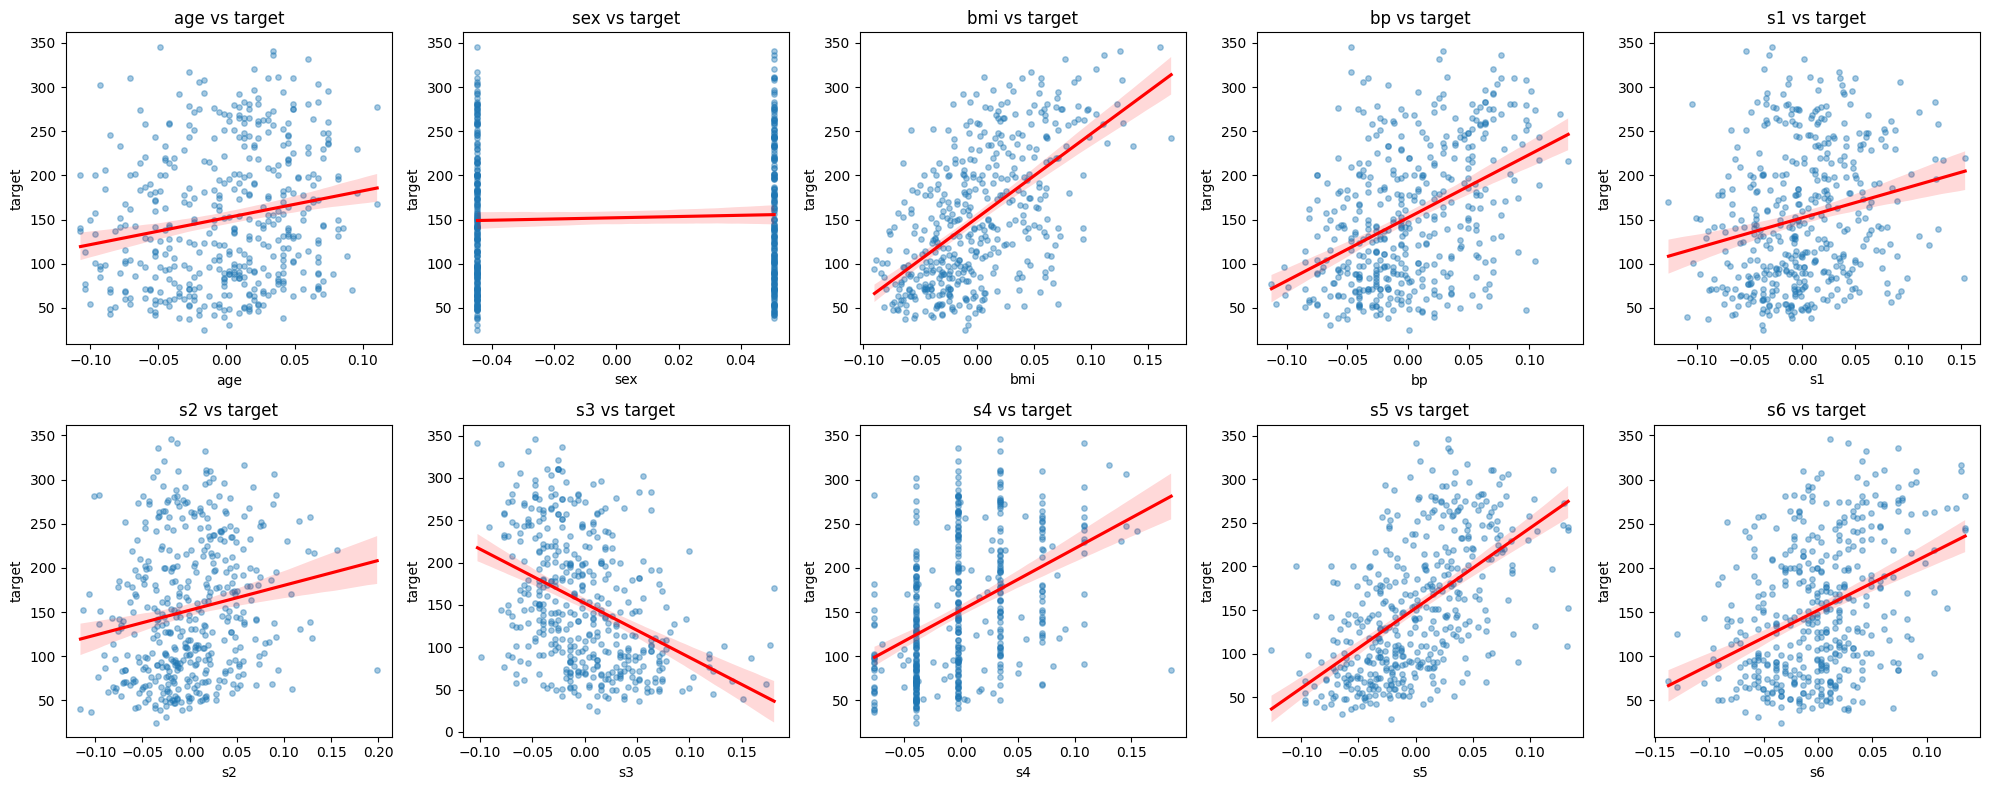

In [17]:
features = X.columns
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.ravel(), features):
    sns.regplot(x=df[col], y=df['target'], ax=ax,
                scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red'})
    ax.set_title(f'{col} vs target')
plt.tight_layout()
plt.show()

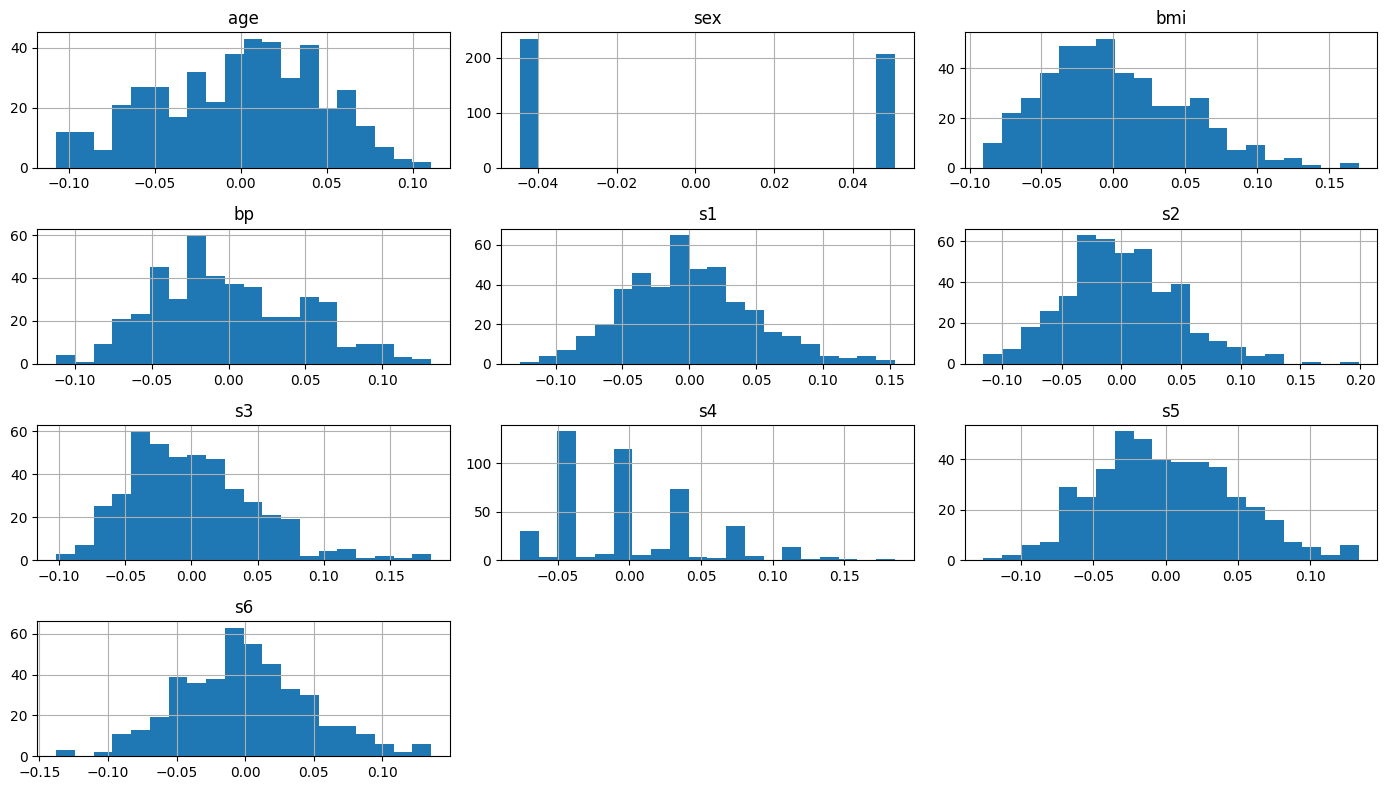

In [8]:
df.drop(columns='target').hist(bins=20, figsize=(14, 8))
plt.tight_layout()
plt.show()

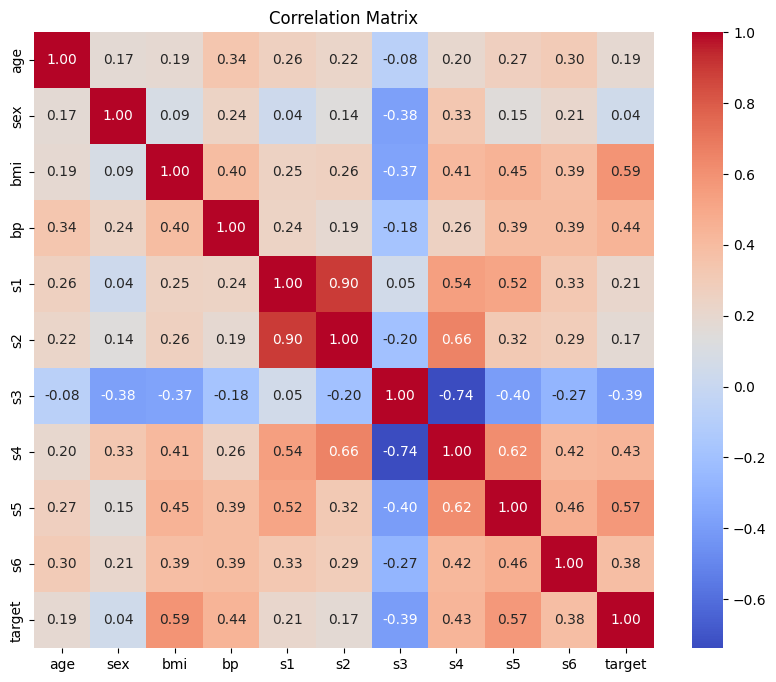

,target
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062
s3,-0.394789


In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

df.corr()['target'].drop('target').sort_values(ascending=False)

The target is right-skewed, ranging from about 25 to 346.
bmi, s5 and bp show the strongest positive correlation with progression, and s3 (HDL) shows a negative one.
sex and age have weak linear relationships.
s1 and s2 are highly correlated with each other (multicollinearity).

- The target is right-skewed, ranging from about 25 to 346.
- bmi, s5 and bp show the strongest positive correlation with progression, and s3 (HDL) shows a negative one.
- sex and age have weak linear relationships.
- s1 and s2 are highly correlated with each other (multicollinearity).

##Building the ANN

In [10]:
def build_model(input_dim, hidden_units=(16, 8), activation='relu',
                lr=0.001, dropout=0.0, l2=0.0):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation=activation,
                               kernel_regularizer=keras.regularizers.l2(l2) if l2 > 0 else None))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))   # linear output, because this is regression
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='mse', metrics=['mae'])
    return model

model = build_model(X_train_s.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Input layer of 10 neurons (one per feature).
Two hidden layers (16 and 8) with ReLU, which handles non-linearity and avoids vanishing gradients.
Output layer of 1 neuron with no activation (linear), because we predict a continuous number.

##Training the ANN Model
The train/test split (80/20, random_state = 42) was done in Section 1, before scaling, to avoid data leakage.

In [11]:
history = model.fit(
    X_train_s, y_train_s,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 3.3829 - mae: 1.5597 - val_loss: 2.7055 - val_mae: 1.3637
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.6930 - mae: 1.3912 - val_loss: 2.1826 - val_mae: 1.2445
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.1528 - mae: 1.2409 - val_loss: 1.7788 - val_mae: 1.1377
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.7372 - mae: 1.1115 - val_loss: 1.4727 - val_mae: 1.0407
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.4258 - mae: 1.0050 - val_loss: 1.2479 - val_mae: 0.9537
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.1980 - mae: 0.9297 - val_loss: 1.0853 - val_mae: 0.8823
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0342 - mae: 0.8687 - val_loss: 0.9667 - val_mae: 0.8287
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9180 - mae: 0.8180 - val_loss: 0.8766 - val_mae: 0.7868
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8342 - mae: 

MSE loss because it is standard for regression,
Adam optimizer because it adapts the learning rate and works well by default,

*   List item
*   List item

and validation_split=0.2 to monitor overfitting during training

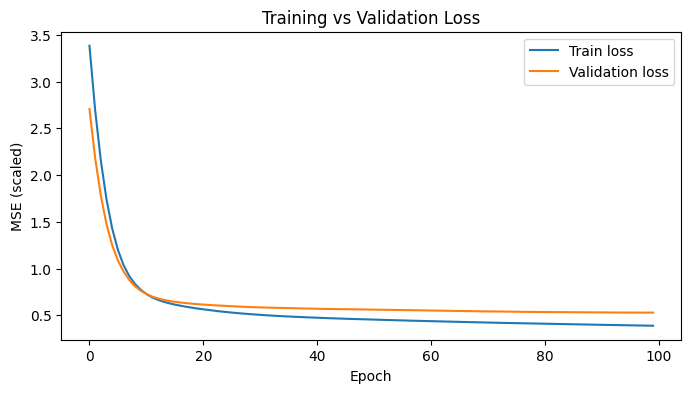

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch'); plt.ylabel('MSE (scaled)')
plt.title('Training vs Validation Loss')
plt.legend(); plt.show()

Both the training loss (≈ 0.39) and the validation loss (≈ 0.53) level off by epoch 100. The gap of about 0.14 between them shows mild overfitting, meaning the model fits the training data slightly better than unseen data.


## Evaluating the Model

In [13]:
def evaluate(model, X, y_true):
    y_pred_s = model.predict(X, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_s).ravel()
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }, y_pred

baseline_metrics, y_pred = evaluate(model, X_test_s, y_test)
print(baseline_metrics)

{'MSE': 2849.280989762308, 'RMSE': np.float64(53.37865668750299), 'MAE': 41.85802575443568, 'R2': 0.4622122723155181}


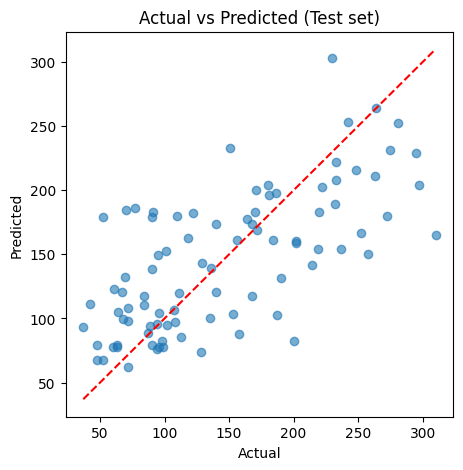

In [14]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Test set)')
plt.show()

On the test set the baseline model achieved MSE = 2849, RMSE = 53.4, MAE = 41.9 and R² = 0.462. This means predictions are typically off by about 53 points on the progression scale, and the model explains about 46% of the variance.

##Improving the Model

In [15]:
experiments = {
    'Baseline (16,8) ReLU':        dict(hidden_units=(16, 8)),
    'Wider (64,32) ReLU':          dict(hidden_units=(64, 32)),
    'Deeper (64,32,16) ReLU':      dict(hidden_units=(64, 32, 16)),
    'Tanh (32,16)':                dict(hidden_units=(32, 16), activation='tanh'),
    'ELU (32,16)':                 dict(hidden_units=(32, 16), activation='elu'),
    'Dropout 0.2 (64,32)':         dict(hidden_units=(64, 32), dropout=0.2),
    'L2 reg 0.01 (64,32)':         dict(hidden_units=(64, 32), l2=0.01),
    'Small LR 0.0005 (32,16)':     dict(hidden_units=(32, 16), lr=0.0005),
    'Large LR 0.01 (32,16)':       dict(hidden_units=(32, 16), lr=0.01),
}

results = []
histories = {}
for name, cfg in experiments.items():
    keras.backend.clear_session()
    tf.random.set_seed(42)
    m = build_model(X_train_s.shape[1], **cfg)
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                       restore_best_weights=True)
    h = m.fit(X_train_s, y_train_s, validation_split=0.2,
              epochs=300, batch_size=32, callbacks=[es], verbose=0)
    metrics, _ = evaluate(m, X_test_s, y_test)
    results.append({'Experiment': name, 'Epochs run': len(h.history['loss']), **metrics})
    histories[name] = h

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.round(3)

,Experiment,Epochs run,MSE,RMSE,MAE,R2
0,"Wider (64,32) ReLU",44,2627.428,51.258,40.310,0.504
1,"Dropout 0.2 (64,32)",45,2665.109,51.625,40.125,0.497
2,"ELU (32,16)",92,2666.498,51.638,41.125,0.497
3,"Deeper (64,32,16) ReLU",27,2732.459,52.273,41.449,0.484
4,"L2 reg 0.01 (64,32)",156,2767.678,52.609,39.721,0.478
5,"Tanh (32,16)",64,2778.776,52.714,41.241,0.476
6,"Small LR 0.0005 (32,16)",123,2846.879,53.356,42.245,0.463
7,"Large LR 0.01 (32,16)",24,2952.499,54.337,42.733,0.443
8,"Baseline (16,8) ReLU",137,2965.180,54.453,43.326,0.440


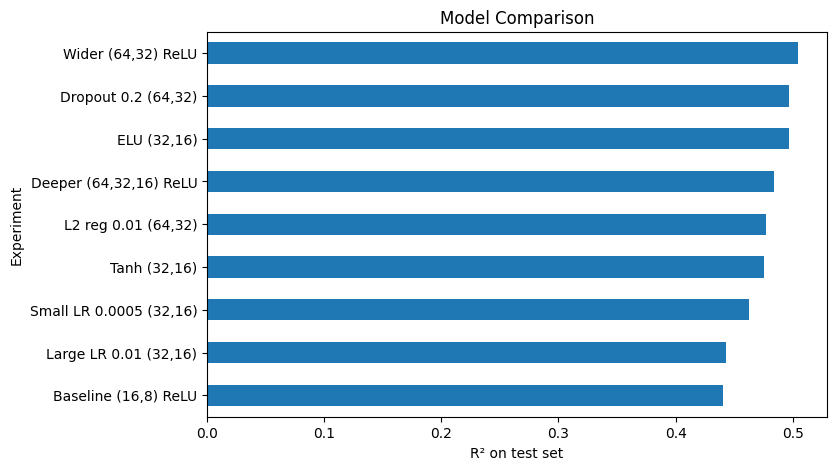

In [16]:
results_df.plot(x='Experiment', y='R2', kind='barh', figsize=(8, 5), legend=False)
plt.xlabel('R² on test set'); plt.title('Model Comparison')
plt.gca().invert_yaxis(); plt.show()

## Results Summary

All nine configurations were trained with early stopping (patience = 20) and evaluated on the same test set. The baseline (16, 8 neurons, ReLU, lr = 0.001) scored R² = 0.440, RMSE = 54.45, MAE = 43.33 and MSE = 2965.

**Best model: Wider (64, 32) with ReLU**
- R² improved from 0.440 to 0.504 (+0.064)
- MSE dropped from 2965 to 2627 (about 11% lower)
- RMSE dropped from 54.45 to 51.26
- MAE dropped from 43.33 to 40.31

**Ranking of all experiments (by R²)**
1. Wider (64,32) ReLU: 0.504
2. Dropout 0.2 (64,32): 0.497
3. ELU (32,16): 0.497
4. Deeper (64,32,16) ReLU: 0.484
5. L2 reg 0.01 (64,32): 0.478
6. Tanh (32,16): 0.476
7. Small LR 0.0005 (32,16): 0.463
8. Large LR 0.01 (32,16): 0.443
9. Baseline (16,8) ReLU: 0.440

**Key findings**
- **Network size:** Increasing the width gave the largest gain. Adding a third layer did not help further (R² = 0.484). It stopped after only 27 epochs, which suggests it overfits quickly on 353 training rows.
- **Regularization:** Dropout (0.497) and L2 (0.478) did not beat the plain wide network on R². L2 gave the lowest MAE of all runs (39.72).
- **Activation functions:** ELU (0.497) and Tanh (0.476) both beat the baseline, and ELU performed better than Tanh.
- **Learning rate:** 0.01 was too high (R² = 0.443, only +0.003 over the baseline). 0.0005 was slower (123 epochs) and gave a small gain (0.463).

**Note:** The top three models are very close (0.504, 0.497, 0.497). With one random seed and only 89 test samples, differences of about 0.01 could be due to chance. The Section 5 baseline (100 epochs, no early stopping) scored R² = 0.462, while the baseline row above was retrained with early stopping.

**Conclusion:** Using a wider network with early stopping gave the best result, improving R² from 0.440 to 0.504. The gains are modest because the dataset is small and noisy.